In [134]:
import pandas as pd

########################
## DATE CONFIGURATION ##
########################
# Edit these dates to test different windows — everything else runs automatically.

# Price data range — outer bounds; must cover both ranking and backtest windows.
DATA_START = pd.Timestamp("1999-01-01")
DATA_END   = pd.Timestamp("2025-12-31")

# Ticker universe — companies in the S&P 500 for this entire span are included.
# Ending before the backtest avoids survivorship bias.
UNIVERSE_END = pd.Timestamp("2014-12-31")

# Ranking window — used to score tickers by their drawdown/recovery history.
# The first year seeds the rolling 52-week high; signals are counted from year 2+.
RANK_START = pd.Timestamp("2003-01-01")
RANK_END   = pd.Timestamp("2014-12-31")

# Backtest window — the period the ranked tickers are actually traded over.
BACKTEST_START = pd.Timestamp("2015-01-01")
BACKTEST_END   = pd.Timestamp("2020-12-31")


In [135]:
import numpy as np
import yfinance as yf

path = "/Users/taytematthews/Backtesting Data/S&P 500 Historical Components & Changes(01-17-2026) (1).csv"

ticker_history = pd.read_csv(path)
ticker_history["date"] = pd.to_datetime(ticker_history["date"])

th_filtered = ticker_history[
    (ticker_history["date"] >= DATA_START) &
    (ticker_history["date"] <= UNIVERSE_END)
]

ticker_sets = th_filtered["tickers"].str.split(",").map(set)
common_tickers = set.intersection(*ticker_sets) if len(ticker_sets) > 0 else set()
len(common_tickers)


227

In [136]:
import os

DATA_CACHE = "/Users/taytematthews/June Backtesting Repo/price_data_cache.pkl"

if os.path.exists(DATA_CACHE):
    data = pd.read_pickle(DATA_CACHE)
    print(f"Loaded cached data from {DATA_CACHE}")
else:
    data = yf.download(
        sorted(common_tickers),
        start=DATA_START, end=DATA_END,
        auto_adjust=False, group_by="ticker", progress=True
    )
    data.to_pickle(DATA_CACHE)
    print(f"Downloaded and cached data to {DATA_CACHE}")


Loaded cached data from /Users/taytematthews/June Backtesting Repo/price_data_cache.pkl


In [137]:
if isinstance(data.columns, pd.MultiIndex): #checks whether dataframe's columns are MultiIndex (e.g. 'AAPL', 'Open')
    open_prices = data.xs("Open", axis=1, level=1).copy() # xs = cross section. Arguments are (key, axis, level). key = value to select, axis = 1 means columns, level = 1 means look at the second level of the Multiindex
    adj_close_prices = data.xs("Adj Close", axis=1, level=1).copy() #getting the adj close prices by selecting the "Adj Close" level of the MultiIndex columns
    volumes = data.xs("Volume", axis=1, level=1).copy() # getting the volume data by selecting the "Volume" level of the MultiIndex columns
else:
    open_prices = data["Open"].copy() # if not multiindex, just select columns directly by name    
    adj_close_prices = data["Adj Close"].copy()
    volumes = data["Volume"].copy()

In [138]:
def compute_recoveries(adj_close_prices, start_date=None, end_date=None, analysis_start=None):

    # Slice to the requested date range (local copy — doesn't modify the global DataFrame)
    if start_date or end_date:
        adj_close_prices = adj_close_prices.loc[start_date:end_date]

    # Default to the first available date if no explicit analysis start is given
    if analysis_start is None:
        analysis_start = adj_close_prices.index[0]

    # min_periods=1 means the rolling window starts immediately rather than waiting
    # for a full 252-day window, so early dates still get a valid high
    rolling_52wk_high = adj_close_prices.rolling(window=252, min_periods=1).max()

    # True wherever a price is 20%+ below its rolling 52-week high
    drawdown_mask = adj_close_prices <= 0.8 * rolling_52wk_high

    recovery_records = []

    for ticker in adj_close_prices.columns:

        prices = adj_close_prices[ticker]

        i = 0
        n = len(prices)

        while i < n:

            date = prices.index[i]
            price = prices.iloc[i]

            # --- ENTER DRAWDOWN ---
            # A new drawdown can only start on/after analysis_start, AND only once
            # the previous drawdown (if any) has fully recovered by +12.5% — this
            # keeps a stock chopping around just below its 80% threshold from being
            # counted as a string of separate drawdowns that are really one decline
            if drawdown_mask.loc[date, ticker] and date >= analysis_start:

                drawdown_date = date
                drawdown_price = price

                target_price = drawdown_price * 1.125  # +12.5% from entry = recovery target

                # --- SEARCH FOR RECOVERY ---
                # Scan every future bar from the entry date looking for the first
                # close that hits the recovery target, recording how many days it took
                recovered = False
                recovery_idx = None

                for j in range(i + 1, n):

                    future_price = prices.iloc[j]

                    if future_price >= target_price:

                        recovery_records.append({
                            "Ticker": ticker,
                            "Drawdown Date": drawdown_date,
                            "Drawdown Price": drawdown_price,
                            "Recovery Date": prices.index[j],
                            "Recovery Price": future_price,
                            "Days To Recovery": j - i,  # calendar trading days, not calendar days
                            "Return": (future_price / drawdown_price) - 1
                        })

                        recovered = True
                        recovery_idx = j
                        break

                if recovered:
                    # Resume scanning from the day AFTER recovery — any drawdown
                    # found from here on is guaranteed to be a fresh, independent
                    # decline rather than a re-dip during the same recovery
                    i = recovery_idx + 1
                    continue
                else:
                    # Never recovered: record it once (NaN fields) so the scoring
                    # step can account for unresolved drawdowns, then stop looking
                    # for further drawdowns on this ticker — by definition we can't
                    # know a "new" drawdown has begun until this one has recovered
                    recovery_records.append({
                        "Ticker": ticker,
                        "Drawdown Date": drawdown_date,
                        "Drawdown Price": drawdown_price,
                        "Recovery Date": pd.NaT,
                        "Recovery Price": np.nan,
                        "Days To Recovery": np.nan,
                        "Return": np.nan
                    })
                    break

            i += 1

    recoveries = pd.DataFrame(recovery_records)

    if len(recoveries) > 0:
        recoveries = recoveries.sort_values(
            ["Drawdown Date", "Ticker"]
        ).reset_index(drop=True)

    return recoveries


In [139]:
from scipy import stats

def make_period_bins(start_date, end_date, step=5): ## 5 years as default, but if you want to do 1 year bins for more granularity, just set step=1 when calling this function in compute_scores() ##
    start_year = pd.to_datetime(start_date).year
    end_year   = pd.to_datetime(end_date).year
    # Floor to the nearest multiple of step so bins always start on a clean boundary
    # e.g. 2003 with step=5 → 2000, not 2003
    start_bin  = (start_year // step) * step
    end_bin    = ((end_year  // step) + 1) * step
    bins   = list(range(start_bin, end_bin + 1, step))
    # Labels are "2000-2004", "2005-2009", etc. — right edge is exclusive in pd.cut
    labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins) - 1)]
    return bins, labels


def compute_scores(recoveries, start_date, end_date, weights=(1, 1, 1)):
    w_dd, w_rec, w_var = weights

    # Count drawdown events and average recovery time per ticker
    summary = recoveries.groupby("Ticker").agg(
        drawdown_count    = ("Ticker", "count"),
        avg_recovery_days = ("Days To Recovery", "mean")
    ).reset_index()

    # Z-score so each component has mean=0, std=1 — prevents one metric from
    # dominating the final score just because of its raw magnitude
    summary["drawdown_score_zscore"] = stats.zscore(summary["drawdown_count"])

    # Tickers whose only recorded drawdown never recovered have avg_recovery_days = NaN;
    # zscore isn't NaN-aware, so a single NaN would turn the WHOLE column into NaN.
    # Fill those with the mean of the known values before z-scoring (same pattern used
    # below for drawdowns_variance), then invert so faster recoveries score higher.
    recovery_days_filled = summary["avg_recovery_days"].fillna(summary["avg_recovery_days"].mean())
    summary["recovery_score_zscore"] = -stats.zscore(recovery_days_filled) ## inverting the recovery score so that faster recoveries (lower days) get higher z-scores, since lower recovery time is better

    # Split drawdown history into 1-year periods to measure consistency over time
    period_bins, period_labels = make_period_bins(start_date, end_date, step=1)

    df_period = recoveries.copy()
    df_period["Drawdown Period"] = pd.cut(
        df_period["Drawdown Date"].dt.year,
        bins=period_bins,
        labels=period_labels,
        right=False,  # left-inclusive: [2000, 2005), [2005, 2010), etc.
    )

    # Count how many drawdowns each ticker had in each 1-year bucket
    drawdown_counts = (
        df_period.dropna(subset=["Drawdown Period"])
        .groupby(["Ticker", "Drawdown Period"])
        .size()
        .unstack(fill_value=0)  # missing period → 0 drawdowns, not NaN
        .rename(columns=lambda x: f"drawdowns_{x}")
    )
    drawdown_cols = list(drawdown_counts.columns)

    # Variance across periods measures consistency: a ticker that draws down
    # regularly in every period is more reliable than one that clusters in one era
    drawdown_counts["drawdowns_variance"] = drawdown_counts[drawdown_cols].var(axis=1, ddof=0)
    summary = summary.merge(
        drawdown_counts[["drawdowns_variance"]].reset_index(),
        on="Ticker", how="left"
    )
    var_vals = summary["drawdowns_variance"].fillna(summary["drawdowns_variance"].mean())
    # Negate so that lower variance → higher z-score (more consistent = better rank)
    summary["variance_zscore"] = -stats.zscore(var_vals)

    # Weighted sum of the three z-scored components → final rank
    summary["final_score"] = (
        w_dd  * summary["drawdown_score_zscore"] +
        w_rec * summary["recovery_score_zscore"] +
        w_var * summary["variance_zscore"]
    )

    return (
        summary[["Ticker", "drawdown_score_zscore", "recovery_score_zscore", "variance_zscore", "final_score"]]
        .sort_values("final_score", ascending=False)
        .reset_index(drop=True)
    )


In [140]:
# ============================================================================
# PARAMETER SWEEP: PERCENTILE FILTERS AND POSITION SIZES
# ============================================================================
# `summary` and `rolling_52wk_high_df` are passed explicitly (rather than read
# from globals) so this same function can be reused by run_scenario() to back-
# test arbitrary ranking/backtest date windows, not just the original one.

def run_backtest(top_percentile, allocation_pct, backtest_start, backtest_end, summary, rolling_52wk_high_df):
    # Build the eligible ticker universe: only tickers whose final_score is at or
    # above the given percentile floor, sorted best-first so higher-ranked stocks
    # get priority when multiple are in drawdown on the same day
    threshold = summary['final_score'].quantile(top_percentile)
    tickers = (summary[summary['final_score'] >= threshold]
           .sort_values('final_score', ascending=False)
           ['Ticker']
           .tolist())

    portfolio = {
        'cash': INITIAL_CASH,
        'open_positions': {},  # keyed by ticker; each value holds shares, buy price, entry date/idx
    }

    closed_trades = []
    equity_history = []

    dates = adj_close_prices.index  # full 1999-2025 index; loop skips pre-backtest dates below

    for date_idx, date in enumerate(dates):
        if date < backtest_start:
            continue  # skip the seed years used only for the 52-week high warm-up
        if date > backtest_end:
            break

        current_position_equity = 0  # reset and recompute from scratch each day
        tickers_to_close = []

        # --- STEP 1: CHECK EXIT CONDITIONS FOR ALL OPEN POSITIONS ---
        # Collect closes separately first so we don't mutate the dict while iterating it
        for ticker in list(portfolio['open_positions'].keys()):
            if ticker not in adj_close_prices.columns:
                continue
            current_price = adj_close_prices.loc[date, ticker]
            if pd.isna(current_price):
                continue

            position = portfolio['open_positions'][ticker]
            buy_price = position['buy_price']
            shares = position['shares']
            price_return = (current_price / buy_price) - 1
            pnl = (current_price - buy_price) * shares

            if price_return >= PROFIT_TARGET_PCT:
                close_reason = 'TAKE_PROFIT'
            elif price_return <= STOP_LOSS_PCT:
                close_reason = 'STOP_LOSS'
            else:
                close_reason = None

            if close_reason:
                tickers_to_close.append({
                    'ticker': ticker,
                    'price': current_price,
                    'shares': shares,
                    'buy_price': buy_price,
                    'pnl': pnl,
                    'pnl_pct': price_return,
                    'reason': close_reason,
                    'entry_date': position['buy_date'],
                    'entry_time_idx': position['entry_time_idx']
                })

        # --- STEP 2: EXECUTE CLOSES, RETURN PROCEEDS TO CASH ---
        for close in tickers_to_close:
            ticker = close['ticker']
            proceeds = close['price'] * close['shares']
            portfolio['cash'] += proceeds
            closed_trades.append({
                'Ticker': ticker,
                'Entry Date': close['entry_date'],
                'Entry Price': close['buy_price'],
                'Shares': close['shares'],
                'Exit Date': date,
                'Exit Price': close['price'],
                'PnL': close['pnl'],
                'PnL %': close['pnl_pct'],
                'Days Held': date_idx - close['entry_time_idx'],
                'Reason': close['reason']
            })
            del portfolio['open_positions'][ticker]

        # --- STEP 3: VALUE REMAINING OPEN POSITIONS AT TODAY'S CLOSE ---
        for ticker in portfolio['open_positions'].keys():
            if ticker not in adj_close_prices.columns:
                continue
            current_price = adj_close_prices.loc[date, ticker]
            if pd.isna(current_price):
                continue
            position = portfolio['open_positions'][ticker]
            current_position_equity += current_price * position['shares']

        # --- STEP 4: SCAN FOR NEW BUY SIGNALS ---
        # Tickers are iterated in score order so capital is deployed to the best-ranked
        # stocks first when cash is limited
        for ticker in tickers:
            if ticker not in adj_close_prices.columns:
                continue
            if ticker in portfolio['open_positions']:  # already holding this stock
                continue

            current_price = adj_close_prices.loc[date, ticker]
            high_52w = rolling_52wk_high_df.loc[date, ticker]
            if pd.isna(current_price) or pd.isna(high_52w):
                continue

            drawdown_pct = (current_price / high_52w) - 1
            if drawdown_pct <= -0.20:  # buy signal: 20%+ below 52-week high
                # Size the position as a fixed % of total current equity (cash + open positions)
                total_equity = portfolio['cash'] + current_position_equity
                position_amount = total_equity * allocation_pct
                if portfolio['cash'] >= position_amount and position_amount > 0:
                    shares = position_amount / current_price
                    portfolio['cash'] -= position_amount
                    # Include the new position in today's equity so the end-of-day
                    # snapshot reflects the true portfolio value (not just leftover cash)
                    current_position_equity += current_price * shares
                    portfolio['open_positions'][ticker] = {
                        'shares': shares,
                        'buy_date': date,
                        'buy_price': current_price,
                        'entry_time_idx': date_idx
                    }

        # --- STEP 5: RECORD END-OF-DAY SNAPSHOT ---
        total_equity = portfolio['cash'] + current_position_equity
        equity_history.append({
            'Date': date,
            'Cash': portfolio['cash'],
            'Position Equity': current_position_equity,
            'Total Equity': total_equity,
            'Open Positions': len(portfolio['open_positions'])
        })

    equity_history_df = pd.DataFrame(equity_history)
    closed_trades_df = pd.DataFrame(closed_trades)

    total_return = (equity_history_df['Total Equity'].iloc[-1] / INITIAL_CASH) - 1
    num_years = (equity_history_df['Date'].iloc[-1] - equity_history_df['Date'].iloc[0]).days / 365.25
    ann_return = (1 + total_return) ** (1 / num_years) - 1 if num_years > 0 else 0
    win_rate = (closed_trades_df['PnL'] > 0).mean() if len(closed_trades_df) > 0 else float('nan')
    expected_value = closed_trades_df['PnL'].mean() if len(closed_trades_df) > 0 else float('nan')

    return {
        'percentile': top_percentile,
        'allocation_pct': allocation_pct,
        'ticker_count': len(tickers),
        'final_equity': equity_history_df['Total Equity'].iloc[-1],
        'total_return': total_return,
        'annualized_return': ann_return,
        'num_trades': len(closed_trades_df),
        'win_rate': win_rate,
        'expected_value': expected_value,
        'equity_curve': equity_history_df,
        'closed_trades': closed_trades_df
    }


In [141]:
##################################
## BACKTEST CONFIGURATION       ##
##################################
INITIAL_CASH      = 100000
PROFIT_TARGET_PCT = 0.125
STOP_LOSS_PCT     = -0.20

percentiles = [0, 0.25, 0.5, 0.75]
allocations  = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]

# Computed once from the full price dataset — reused by every run_scenario() call
rolling_52wk_high = adj_close_prices.rolling(window=252, min_periods=1).max()


In [142]:
## RUN THE FULL PIPELINE (RANK -> SCORE -> BACKTEST SWEEP) FOR A CUSTOM DATE WINDOW ##

def run_scenario(rank_start, rank_end, backtest_start, backtest_end,
                 percentiles=(0, 0.25, 0.5, 0.75),
                 allocations=(0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10),
                 label=None):
    """
    Re-runs the entire ranking -> scoring -> backtest-sweep pipeline for an
    arbitrary pair of windows, so you can see how the SAME methodology performs
    when it's trained and traded on different historical market regimes:

      - rank_start / rank_end       : the period compute_recoveries/compute_scores
                                      uses to rank tickers by drawdown behavior
      - backtest_start / backtest_end : the period the ranked tickers are traded over

    Reuses the existing price universe (`adj_close_prices`) and the global
    `rolling_52wk_high` — only the date windows and resulting scores change.
    """
    rank_start = pd.Timestamp(rank_start)
    rank_end   = pd.Timestamp(rank_end)
    backtest_start = pd.Timestamp(backtest_start)
    backtest_end   = pd.Timestamp(backtest_end)

    # Mirrors the original start_date=1999 / analysis_start=2000 split: the first
    # year of the ranking window seeds the rolling 52-week high, and drawdown
    # signals are only counted from the following year onward
    analysis_start = rank_start + pd.DateOffset(years=1)

    scenario_recoveries = compute_recoveries(
        adj_close_prices,
        start_date=rank_start,
        end_date=rank_end,
        analysis_start=analysis_start
    )
    scenario_summary = compute_scores(scenario_recoveries, rank_start, rank_end)

    scenario_results = []
    for pct in percentiles:
        for alloc in allocations:
            result = run_backtest(pct, alloc, backtest_start, backtest_end,
                                  scenario_summary, rolling_52wk_high)
            scenario_results.append(result)

    return {
        'label': label or (f"Rank {rank_start.date()}–{rank_end.date()}  →  "
                           f"Backtest {backtest_start.date()}–{backtest_end.date()}"),
        'rank_start': rank_start, 'rank_end': rank_end,
        'backtest_start': backtest_start, 'backtest_end': backtest_end,
        'recoveries': scenario_recoveries,
        'summary': scenario_summary,
        'results': scenario_results,
    }


Rank 2003-01-01–2014-12-31  →  Backtest 2015-01-01–2020-12-31
 Percentile Position Size  Final Equity  Total Return %  Annualized Return %  Trades  Win Rate %
       0.00            1% 172462.663328       72.462663             9.515654    1424   72.823034
       0.00           10% 166160.873509       66.160874             8.837854     250   68.800000
       0.00            2% 205012.646803      105.012647            12.719495    1039   71.799808
       0.00            3% 203841.860785      103.841861            12.611879     763   70.642202
       0.00            4% 219327.650305      119.327650            13.995533     622   70.578778
       0.00            5% 196839.317801       96.839318            11.957248     499   69.739479
       0.00            6% 206827.497162      106.827497            12.885304     426   69.953052
       0.00            7% 162664.218747       62.664219             8.452473     363   68.044077
       0.00            8% 153045.678218       53.045678          

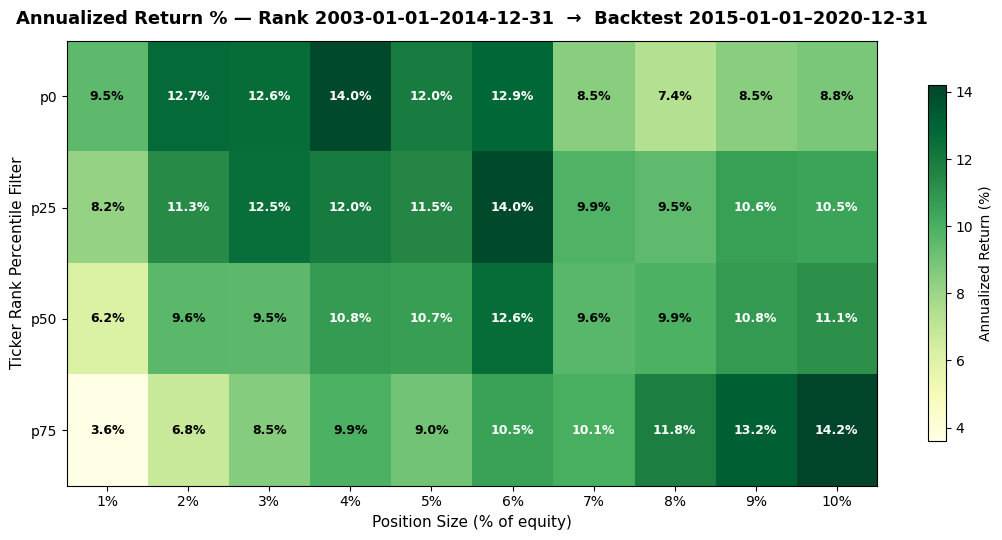

In [143]:
scenario_A = run_scenario(
    rank_start     = RANK_START,
    rank_end       = RANK_END,
    backtest_start = BACKTEST_START,
    backtest_end   = BACKTEST_END,
)

# ── summary table ─────────────────────────────────────────────────────────────
scenario_A_df = pd.DataFrame([
    {
        'Percentile':          r['percentile'],
        'Position Size':       f"{int(r['allocation_pct']*100)}%",
        'Final Equity':        r['final_equity'],
        'Total Return %':      r['total_return'] * 100,
        'Annualized Return %': r['annualized_return'] * 100,
        'Trades':              r['num_trades'],
        'Win Rate %':          r['win_rate'] * 100 if not pd.isna(r['win_rate']) else float('nan'),
    }
    for r in scenario_A['results']
]).sort_values(['Percentile', 'Position Size']).reset_index(drop=True)

print(scenario_A['label'])
print(scenario_A_df.to_string(index=False))

# ── annualized-return heatmap ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

pct_vals   = sorted({r['percentile']    for r in scenario_A['results']})
alloc_vals = sorted({r['allocation_pct'] for r in scenario_A['results']})

matrix = np.array([
    [
        next(
            (r['annualized_return'] * 100
             for r in scenario_A['results']
             if r['percentile'] == pct and abs(r['allocation_pct'] - alloc) < 1e-9),
            float('nan')
        )
        for alloc in alloc_vals
    ]
    for pct in pct_vals
])

row_labels = [f"p{int(p*100)}" for p in pct_vals]
col_labels = [f"{int(a*100)}%"  for a in alloc_vals]

fig, ax = plt.subplots(figsize=(max(6, len(col_labels) * 1.1), len(row_labels) + 1.5))
im = ax.imshow(matrix, cmap="YlGn", aspect="auto",
               vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))

ax.set_xticks(range(len(col_labels)));  ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(len(row_labels)));  ax.set_yticklabels(row_labels, fontsize=10)
ax.set_xlabel("Position Size (% of equity)", fontsize=11)
ax.set_ylabel("Ticker Rank Percentile Filter", fontsize=11)
ax.set_title(f"Annualized Return % — {scenario_A['label']}",
             fontsize=13, fontweight="bold", pad=12)

norm_range = np.nanmax(matrix) - np.nanmin(matrix)
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        val = matrix[i, j]
        if not np.isnan(val):
            brightness = (val - np.nanmin(matrix)) / (norm_range + 1e-9)
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=9,
                    color="white" if brightness > 0.6 else "black", fontweight="bold")

plt.colorbar(im, ax=ax, label="Annualized Return (%)", shrink=0.8)
plt.tight_layout()
plt.show()


In [144]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Download S&P 500 over the full data range so it covers any backtest window
sp500_data = yf.download("^GSPC", start=DATA_START, end=DATA_END, progress=False)

def _extract_close(df):
    if "Adj Close" in df.columns: return df["Adj Close"]
    if "Close"     in df.columns: return df["Close"]
    if isinstance(df.columns, pd.MultiIndex):
        for col in df.columns:
            if "Adj" in str(col) or "Close" in str(col): return df[col]
    return df.iloc[:, 0]

sp500_prices = _extract_close(sp500_data).squeeze()


def plot_equity_vs_sp500(result, title=None):
    eq = result["equity_curve"].copy()
    eq["Date"] = pd.to_datetime(eq["Date"])
    eq = eq.set_index("Date")

    sp = sp500_prices.loc[eq.index[0] : eq.index[-1]].copy()

    eq_norm = eq["Total Equity"] / eq["Total Equity"].iloc[0] * INITIAL_CASH
    sp_norm = sp / sp.iloc[0] * INITIAL_CASH

    pct_str   = f"p{int(result['percentile'] * 100)}"
    alloc_str = f"{int(result['allocation_pct'] * 100)}%"
    ann       = result["annualized_return"] * 100
    wr        = result["win_rate"] * 100 if not pd.isna(result["win_rate"]) else float("nan")

    sp_years = (sp.index[-1] - sp.index[0]).days / 365.25
    sp_ann   = ((sp_norm.iloc[-1] / sp_norm.iloc[0]) ** (1 / sp_years) - 1) * 100 if sp_years > 0 else float("nan")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(eq_norm.index, eq_norm.values, color="#2563EB", linewidth=1.8,
            label=f"Strategy ({pct_str}, {alloc_str}) — {ann:.1f}% ann., {wr:.1f}% win rate")
    ax.plot(sp_norm.index, sp_norm.values, color="#9CA3AF", linewidth=1.4, linestyle="--",
            label=f"S&P 500 buy & hold — {sp_ann:.1f}% ann.")

    ax.set_title(title or f"{scenario_A['label']}  |  {pct_str}, {alloc_str} alloc",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel(f"Portfolio Value (starting ${INITIAL_CASH:,.0f})")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [145]:
import ipywidgets as widgets
from IPython.display import display, clear_output

pct_options_eq   = sorted({r["percentile"]    for r in scenario_A["results"]})
alloc_options_eq = sorted({r["allocation_pct"] for r in scenario_A["results"]})

pct_dropdown_eq = widgets.Dropdown(
    options     = [(f"p{int(p*100)}", p) for p in pct_options_eq],
    description = "Percentile:",
)
alloc_dropdown_eq = widgets.Dropdown(
    options     = [(f"{int(a*100)}%", a) for a in alloc_options_eq],
    description = "Position Size:",
)
out_eq = widgets.Output()

def show_equity(_=None):
    pct   = pct_dropdown_eq.value
    alloc = alloc_dropdown_eq.value
    match = next(
        (r for r in scenario_A["results"]
         if r["percentile"] == pct and abs(r["allocation_pct"] - alloc) < 1e-9),
        None,
    )
    with out_eq:
        clear_output(wait=True)
        if match is None:
            print("No result found for this combination.")
        else:
            plot_equity_vs_sp500(match)

pct_dropdown_eq.observe(show_equity,   names="value")
alloc_dropdown_eq.observe(show_equity, names="value")

display(widgets.HBox([pct_dropdown_eq, alloc_dropdown_eq]), out_eq)
show_equity()


Output()